In [8]:
# Packages needed
import matplotlib.pyplot as plt
import pandas as pd

In [10]:
class Learningcurve:

    def __init__(self, file_path: str):
        self.file_path = file_path
        self.df = None
        self._load_data()

    def _load_data(self):
        self.df = pd.read_csv(self.file_path)
        self.df["session"] = self.df.groupby("Maze_ID").cumcount() + 1

    def plot_sessions(self, output_file: str = None):
        
        if self.df is None:
            print("No data available to plot.")
            return
        
        plt.figure(figsize=(10, 6))

        unique_mazes =  sorted(self.df["Maze_ID"].unique())

        for maze in unique_mazes:
            maze_data = self.df[self.df["Maze_ID"] == maze]

            plt.plot(
                maze_data["session"],   # X-axis: session number
                maze_data["time_taken"],# Y-axis: time taken
                label=f"Maze {maze}",   # Legend label
                marker="o",             # Adds dot
                markersize=10,          # Dot size
                linewidth=2,            # Line width
                alpha=0.8,              # Transparency of lines and dots
            )

        plt.title("Time Taken Across 5 Sessions by Maze ID", fontsize=14, pad=15)
        plt.xlabel("Session Number", fontsize=12)
        plt.ylabel("Time Taken (seconds)", fontsize=12)

        plt.xticks(self.df["session"].unique())
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend(title="Maze IDs", bbox_to_anchor=(1, 1), loc="upper left")
        plt.tight_layout()

        # Save or show the plot
        if output_file:
            plt.savefig(output_file, dpi=300)
            print(f"Plot saved successfully to {output_file}")
        else:
            plt.show()

        plt.close()


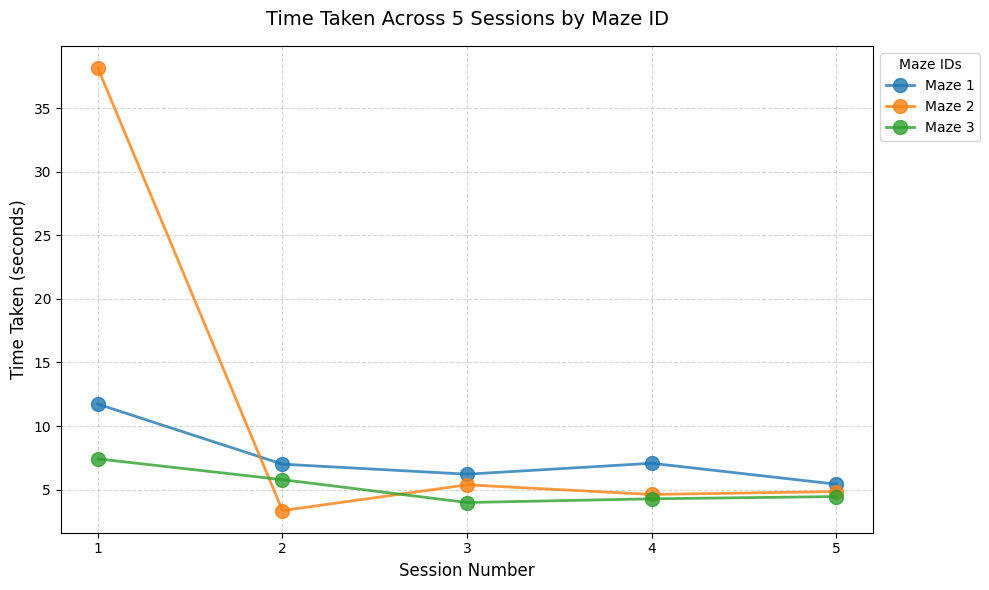

In [11]:
# Example usage:
session1 = Learningcurve("PID11_SESSION1.csv")
session1.plot_sessions()

In [ ]:
# Saving the image as a .png file (THIS SAVES THE IMAGE IN THE REPO!)
session1.plot_sessions(output_file="session1_plot.png")

Plot saved successfully to session1_plot.png
